<a href="https://colab.research.google.com/github/adelliamulyana-collab/UTS_DataMining_2404030048/blob/main/UTS_Data_MIning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [18]:
from google.colab import drive
drive.mount('/content/drive')
#Untuk menghubungkan dan mengirim file dari google drive

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [19]:
import pandas as pd
import numpy as np
import statsmodels.api as sm

import matplotlib.pyplot as plt
import seaborn as sb
from sklearn.metrics import accuracy_score
#Deklarasi

In [20]:
#Menampilkan data
test=pd.read_csv('/content/drive/MyDrive/data mining_data/data_testing.csv')
train=pd.read_csv('/content/drive/MyDrive/data mining_data/data_training.csv')
test
train

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,Id
0,7.3,0.740,0.08,1.7,0.094,10.0,45.0,0.99576,3.24,0.50,9.8,5,1366
1,8.1,0.575,0.22,2.1,0.077,12.0,65.0,0.99670,3.29,0.51,9.2,5,103
2,10.1,0.430,0.40,2.6,0.092,13.0,52.0,0.99834,3.22,0.64,10.0,7,942
3,12.9,0.500,0.55,2.8,0.072,7.0,24.0,1.00012,3.09,0.68,10.9,6,811
4,8.4,0.360,0.32,2.2,0.081,32.0,79.0,0.99640,3.30,0.72,11.0,6,918
...,...,...,...,...,...,...,...,...,...,...,...,...,...
852,6.7,1.040,0.08,2.3,0.067,19.0,32.0,0.99648,3.52,0.57,11.0,4,1467
853,8.0,0.390,0.30,1.9,0.074,32.0,84.0,0.99717,3.39,0.61,9.0,5,1533
854,7.4,0.350,0.33,2.4,0.068,9.0,26.0,0.99470,3.36,0.60,11.9,6,1580
855,7.9,0.570,0.31,2.0,0.079,10.0,79.0,0.99677,3.29,0.69,9.5,6,1216


In [21]:
train.head()
test.head()
#menampilkan 5 data

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,Id
0,6.8,0.61,0.04,1.5,0.057,5.0,10.0,0.99525,3.42,0.60,9.500000,222
1,6.9,0.84,0.21,4.1,0.074,16.0,65.0,0.99842,3.53,0.72,9.233333,1514
2,7.0,0.58,0.12,1.9,0.091,34.0,124.0,0.99560,3.44,0.48,10.500000,417
3,7.8,0.48,0.68,1.7,0.415,14.0,32.0,0.99656,3.09,1.06,9.100000,754
4,12.5,0.60,0.49,4.3,0.100,5.0,14.0,1.00100,3.25,0.74,11.900000,516


In [22]:
train.info()
test.info()
#menampilkan informasi dataset

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 857 entries, 0 to 856
Data columns (total 13 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         857 non-null    float64
 1   volatile acidity      857 non-null    float64
 2   citric acid           857 non-null    float64
 3   residual sugar        857 non-null    float64
 4   chlorides             857 non-null    float64
 5   free sulfur dioxide   857 non-null    float64
 6   total sulfur dioxide  857 non-null    float64
 7   density               857 non-null    float64
 8   pH                    857 non-null    float64
 9   sulphates             857 non-null    float64
 10  alcohol               857 non-null    float64
 11  quality               857 non-null    int64  
 12  Id                    857 non-null    int64  
dtypes: float64(11), int64(2)
memory usage: 87.2 KB
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 286 entries, 0 to 285
Data c

In [23]:
train.isnull().sum()
#mendeteksi data yang hilang(missing values)
#tidak ada misssing values

,0
fixed acidity,0
volatile acidity,0
citric acid,0
residual sugar,0
chlorides,0
free sulfur dioxide,0
total sulfur dioxide,0
density,0
pH,0
sulphates,0


In [24]:
train = train.dropna()
#Untuk menghapus missing values

In [25]:
train = train.drop_duplicates()
#Untuk menghapus data yang memiliki duplikat

In [26]:
X = train.drop('quality', axis=1)
#X berisi fitur-fitur kimia wine
y = train['quality']
#Y Berisi label kualitas wine


In [27]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)
#Dataset dibagi menjadi 80% data training dan 20% data testing

In [28]:
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(random_state=42)

model.fit(X_train, y_train)
#Random Forest digunakan karena mampu menghasilkan performa klasifikasi yang baik dan stabil

RandomForestClassifier(random_state=42)

In [29]:
y_pred = model.predict(X_test)
#Prediksi data Testing Internal

In [30]:
print("Accuracy:", accuracy_score(y_test, y_pred))
#Accuracy digunakan untuk mengukur seberapa baik model dalam memprediksi kualitas wine.

Accuracy: 0.5930232558139535


In [31]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))
#Laporah Hasil klasifikasi untuk mengevaluasi model klasifikasi

              precision    recall  f1-score   support

           4       0.00      0.00      0.00         3
           5       0.65      0.70      0.68        67
           6       0.58      0.59      0.59        78
           7       0.43      0.43      0.43        21
           8       0.00      0.00      0.00         3

    accuracy                           0.59       172
   macro avg       0.33      0.34      0.34       172
weighted avg       0.57      0.59      0.58       172



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [32]:
prediksi = model.predict(test)
#Model digunakan untuk memprediksi kualitas wine pada dataset testing.

In [34]:
hasil = pd.DataFrame({
    'id': test['Id'],
    'quality': prediksi
})

In [35]:
hasil

,id,quality
0,222,5
1,1514,5
2,417,5
3,754,5
4,516,5
...,...,...
281,1147,6
282,296,5
283,170,5
284,1439,5


In [43]:
train['quality'].value_counts()

,count
quality,
5,362
6,341
7,109
4,26
8,13
3,6


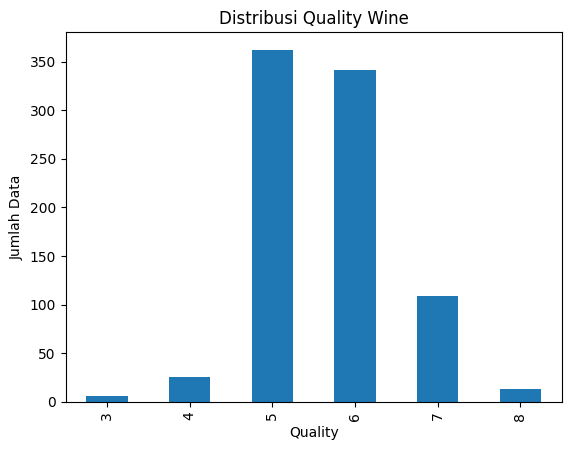

In [37]:
import matplotlib.pyplot as plt

train['quality'].value_counts().sort_index().plot(kind='bar')

plt.xlabel('Quality')
plt.ylabel('Jumlah Data')
plt.title('Distribusi Quality Wine')

plt.show()
#Visualisasi distribusi kualitas wine dan jumlah data

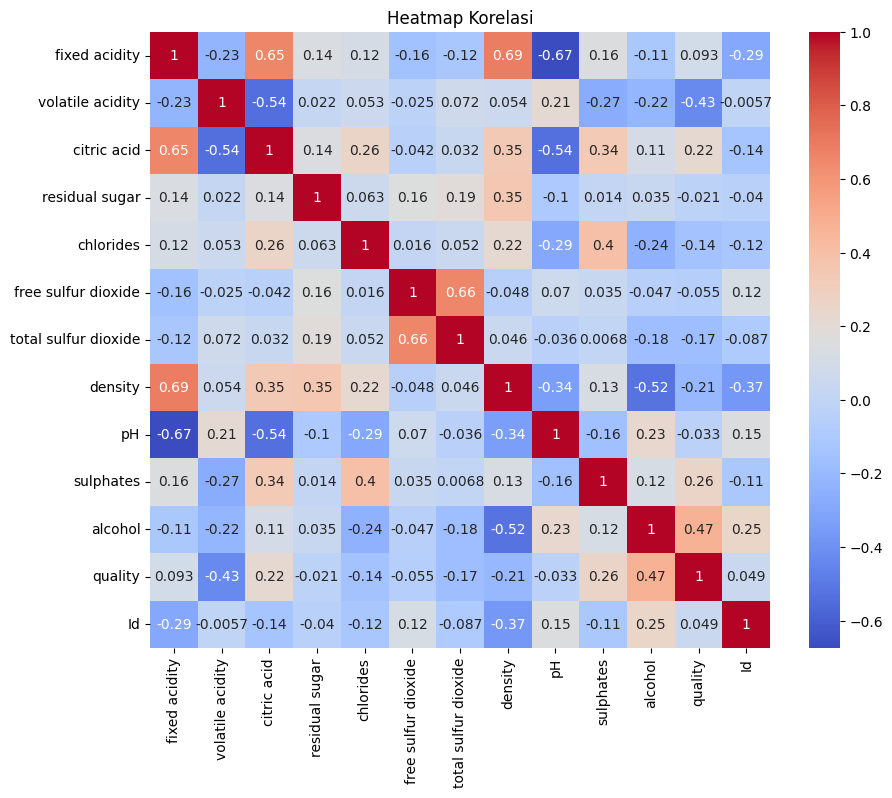

In [38]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10,8))

sns.heatmap(train.corr(), annot=True, cmap='coolwarm')

plt.title('Heatmap Korelasi')

plt.show()
#untuk melihat sejauh mana hubungan linear antara dua variabel dalam sebuah dataset
#Faktor Penentu kualitas : Alkohol, Sulphates, dan citric acid

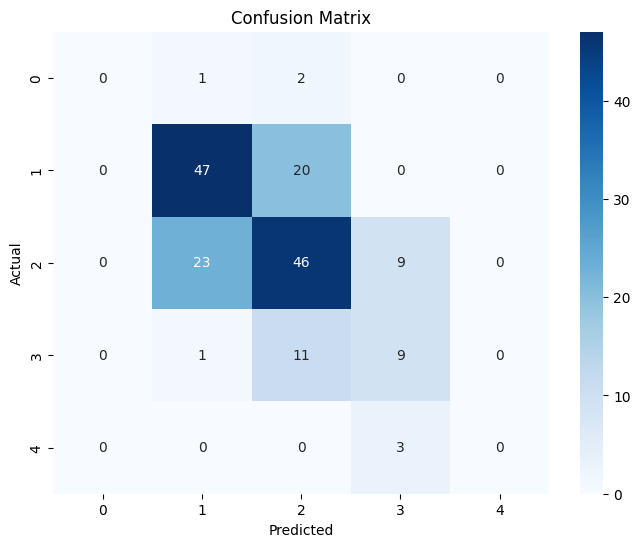

In [40]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(8,6))

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')

plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')

plt.show()
#Kelas 1: Paling sukses, model menebak 47 data dengan benar.
#Kelas 2: Berhasil menebak 46 data dengan benar.
#Kelas 3: Hanya 9 data yang tertebak benar.
#Kelas 0 & 4: Gagal total. Model tidak berhasil menebak satu pun data di kelas ini (skor 0).

In [42]:
hasil.to_csv('hasil_prediksi.csv', index=False)
from google.colab import files

files.download('hasil_prediksi.csv')
#Download Data

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

**KESIMPULAN**



---
Kualitas :   




```


 3      4      5      6       7     8



```



---

Banyak Data :


```
6     26     362     341     109     13
```



---
Faktor yang memengaruhi kualitas wine :  Alkohol, Sulphates, dan citric acid

